In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print(f'version del tensorflow: {tf.__version__}')

version del tensorflow: 2.20.0


In [3]:
#cargar datos 
(x_train, _), (x_test, _) = mnist.load_data()

#convertir valores de 0-255 a 0.0-1.0
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f'Imágenes de entrenamiento: {x_train.shape}')
print(f'Imágenes de prueba: {x_test.shape}')

Imágenes de entrenamiento: (60000, 28, 28, 1)
Imágenes de prueba: (10000, 28, 28, 1)


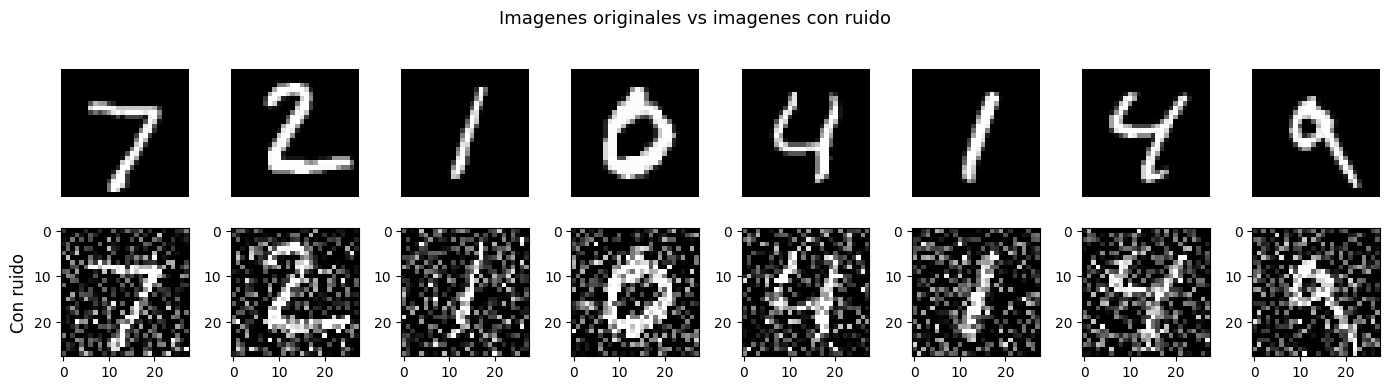

In [5]:
#generar imagenes con la funcion ruido
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(0, 1,x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1,x_test.shape)

#asegurar que los valores se mantengan entre 0 y 1
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

#visualizar modelo original vs modelo con ruido
fig, axes = plt.subplots(2, 8, figsize = (14, 4))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    
axes[0, 0].set_ylabel('Original', fontsize = 12)
axes[1, 0].set_ylabel('Con ruido', fontsize = 12)
plt.suptitle('Imagenes originales vs imagenes con ruido', fontsize = 13)
plt.tight_layout()
plt.show()

In [7]:
#modelo autoenconder denoising
def build_autoencoder():

    input_img = layers.Input(shape=(28, 28, 1))

    
    #primer y segunda capa
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) 

    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    #reconstruir desde la representación comprimida
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    autoencoder = models.Model(input_img, decoded)
    
    return autoencoder


# Construir y compilar el modelo
autoencoder = build_autoencoder()
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'  
)


autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#entrenamient del modelo
history = autoencoder.fit(
    x_train_noisy, x_train,     
    epochs=8,                        
    batch_size=128,                   
    validation_data=(x_test_noisy, x_test)  # evaluar en datos de prueba
)

print('\n Entrenamiento finalizado.')

Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 242ms/step - loss: 0.1738 - val_loss: 0.1079
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 240ms/step - loss: 0.1043 - val_loss: 0.0998
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 240ms/step - loss: 0.0990 - val_loss: 0.0963
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - loss: 0.0963 - val_loss: 0.0944
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 238ms/step - loss: 0.0946 - val_loss: 0.0931
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 235ms/step - loss: 0.0934 - val_loss: 0.0919
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 238ms/step - loss: 0.0925 - val_loss: 0.0915
Epoch 8/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - loss: 0.0918 - val_loss: 0.0908

 Entrenamiento finalizado.


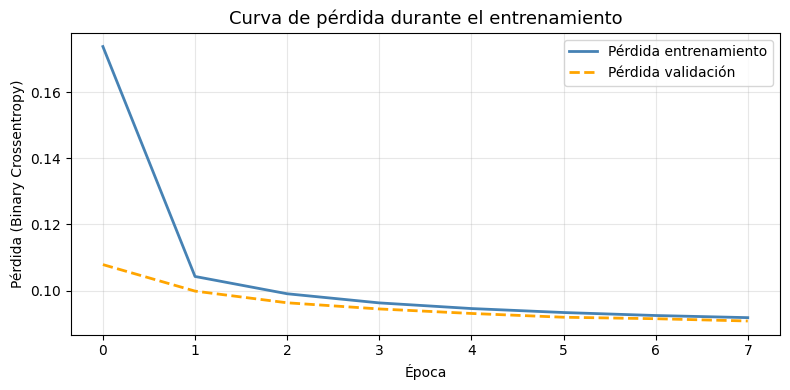

Pérdida final (entrenamiento): 0.0918
Pérdida final (validación):    0.0908


In [9]:
#graficar la pérdida durante el entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Pérdida entrenamiento', color='steelblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Pérdida validación',    color='orange',   linewidth=2, linestyle='--')
plt.title('Curva de pérdida durante el entrenamiento', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir pérdida final
print(f"Pérdida final (entrenamiento): {history.history['loss'][-1]:.4f}")
print(f"Pérdida final (validación):    {history.history['val_loss'][-1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


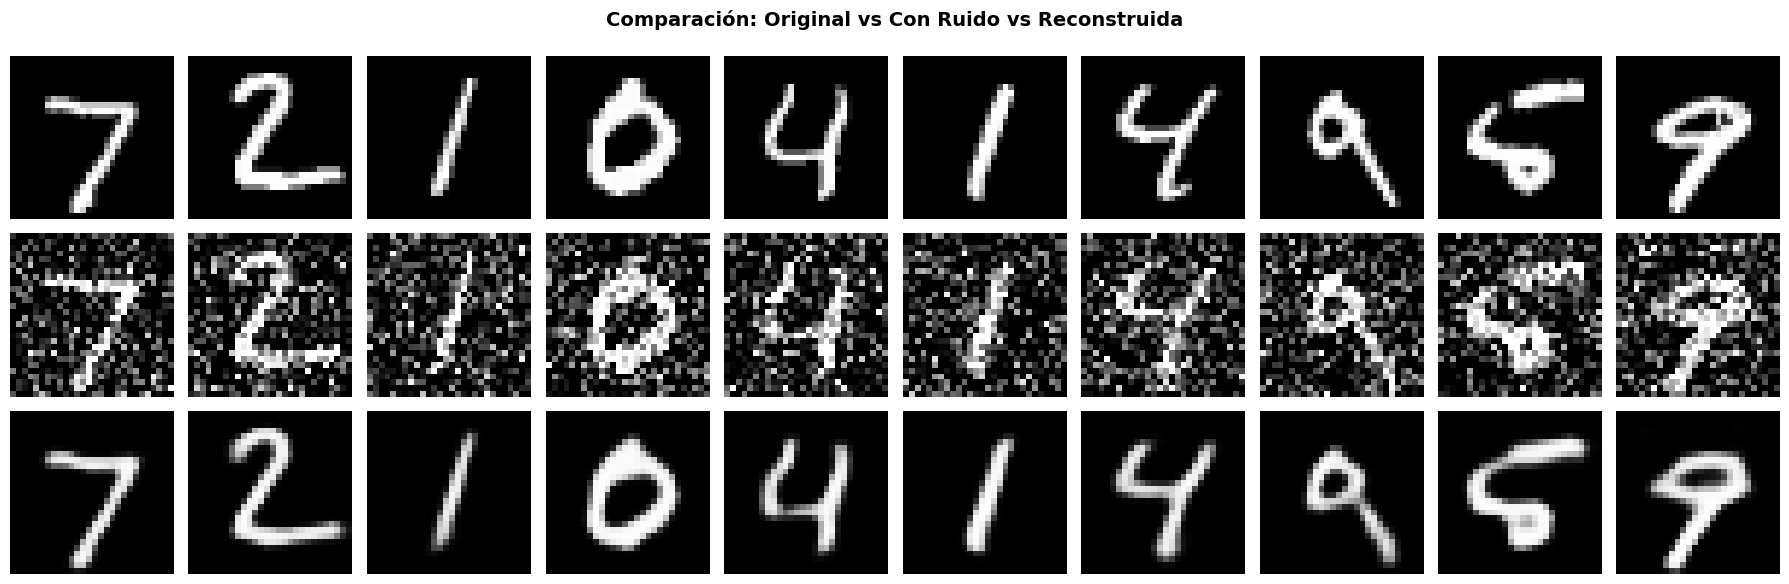

In [10]:
#comparación de Original, Con Ruido y Reconstruida
x_test_reconstructed = autoencoder.predict(x_test_noisy)
 
n = 10  
fig, axes = plt.subplots(3, n, figsize=(18, 6))

etiquetas = ['Original', 'Con Ruido', 'Reconstruida']
datos     = [x_test, x_test_noisy, x_test_reconstructed]

for row, (datos_fila, etiqueta) in enumerate(zip(datos, etiquetas)):
    for col in range(n):
        ax = axes[row, col]
        ax.imshow(datos_fila[col].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    axes[row, 0].set_ylabel(etiqueta, fontsize=12, fontweight='bold')

plt.suptitle('Comparación: Original vs Con Ruido vs Reconstruida', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Calcular MSE
mse_ruido        = np.mean((x_test - x_test_noisy) ** 2)
mse_reconstruida = np.mean((x_test - x_test_reconstructed) ** 2)

print('=' * 45)
print('       MÉTRICAS DE CALIDAD (MSE)')
print('=' * 45)
print(f'  MSE imagen con ruido:       {mse_ruido:.5f}')
print(f'  MSE imagen reconstruida:    {mse_reconstruida:.5f}')
mejora = (1 - mse_reconstruida / mse_ruido) * 100
print(f'  Mejora de calidad:          {mejora:.1f}%')
print('=' * 45)

if mse_reconstruida < mse_ruido:
    print('El modelo reconstruyó imágenes de MEJOR calidad que las ruidosas.')
else:
    print('El modelo no mejoró la calidad. Considera más épocas de entrenamiento.')